# TRABAJO Parte 2: AIA_2024-2025

# Transfer Learning con CNNs - Dataset: Flowers

# a) Carga de datos

In [ ]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import pandas as pd

import pathlib
import os
import glob
import shutil
tf.__version__

'2.18.0'

In [ ]:
import warnings
warnings.filterwarnings('ignore')

Descargamos el dataset que pone a nuestra disposición Tensorflow.

In [ ]:
_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

zip_file = tf.keras.utils.get_file(origin=_URL,
                                   fname="flower_photos.tgz",
                                   extract=True,
                                   )

base_dir = os.path.join(os.path.dirname(zip_file), 'flower_photos')

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Tras completar la descarga, debemos tener la siguiente estructura de directorios:  

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>~/.keras/datasets/flower_photos_extracted/flower_photos</b>
|__ <b>daisy</b>
|__ <b>dandelion</b>
|__ <b>roses</b>
|__ <b>sunflowers</b>
|__ <b>tulips</b>
</pre>

Desgraciadamente, para este dataset, Tensorflow no nos proporciona la estructura de directorios necesaria de train y de validación. Por lo que debemos proceder del siguiente modo:

* Crear una carpeta `train` y de `val`, cada una de ellas debe contener a su vez, cinco subdirectorios: uno para cada clase de flor.
* Moveremos las imágenes de las carpetas originales a estas nuevas carpetas. De modo que el 80% de las imágenes vayan al conjunto de train y el 20% restante al de validación.
* La estructura final de directorios debe ser la siguiente:

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>~/.keras/datasets/flower_photos_extracted/flower_photos</b>
|__ <b>train</b>
    |______ <b>daisy</b>: [12.jpg, 28.jpg, 31.jpg ....]
    |______ <b>dandelion</b>: [41.jpg, 22.jpg, 35.jpg ....]
    |______ <b>roses</b>: [121.jpg, 92.jpg, 38.jpg ....]
    |______ <b>sunflowers</b>: [93.jpg, 23.jpg, 83.jpg ....]
    |______ <b>tulips</b>: [109.jpg, 267.jpg, 93.jpg ....]
 |__ <b>val</b>
    |______ <b>daisy</b>: [507.jpg, 508.jpg, 509.jpg ....]
    |______ <b>dandelion</b>: [719.jpg, 720.jpg, 721.jpg ....]
    |______ <b>roses</b>: [514.jpg, 515.jpg, 516.jpg ....]
    |______ <b>sunflowers</b>: [560.jpg, 561.jpg, 562.jpg .....]
    |______ <b>tulips</b>: [640.jpg, 641.jpg, 642.jpg ....]
</pre>

Creamos una lista con el nombre de las 5 clases. En castellano sería: margaritas, diente de león, rosas, girasoles y tulipanes.

In [ ]:
classes = ['roses', 'daisy', 'dandelion', 'sunflowers', 'tulips']

Creemos la estructura de directorios necesaria:

In [ ]:
base_dir = os.path.expanduser("~/.keras/datasets/flower_photos_extracted/flower_photos/")

Preparamos variables con las rutas de los diferentes directorios a crear:

In [ ]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

daisy_dir = os.path.join(train_dir, 'daisy')
dandelion_dir = os.path.join(train_dir, 'dandelion')
roses_dir = os.path.join(train_dir, 'roses')
sunflowers_dir = os.path.join(train_dir, 'sunflowers')
tulips_dir = os.path.join(train_dir, 'tulips')

In [ ]:
SPLIT_RATIO=0.8

for cl in classes:
    # path de las imagenes de la clase cl
    img_path = os.path.join(base_dir, cl)

    # obtenemos la lista de todas las imagenes
    images = glob.glob(img_path + '/*.jpg')
    print("{}: {} Imagenes".format(cl, len(images)))

    # determinamos cuantas imagenes son el 80%
    num_train = int(round(len(images)*SPLIT_RATIO))

    # separamos las imagenes en dos listas
    train, val = images[:num_train], images[num_train:]

    # creamos la carpeta de train/clase y val/clase
    if not os.path.exists(os.path.join(base_dir, 'train', cl)):
        os.makedirs(os.path.join(base_dir, 'train', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'train', cl))

    if not os.path.exists(os.path.join(base_dir, 'val', cl)):
        os.makedirs(os.path.join(base_dir, 'val', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'val', cl))

    for t in train:
        shutil.move(t, os.path.join(base_dir, 'train', cl))

    for v in val:
        shutil.move(v, os.path.join(base_dir, 'val', cl))


roses: 641 Imagenes
daisy: 633 Imagenes
dandelion: 898 Imagenes
sunflowers: 699 Imagenes
tulips: 799 Imagenes


**Tarea 1: Muestre el nombre de dos ficheros cualquiera en alguna de esas rutas**

Por ejemplo, se va a mostrar el nombre del primer fichero de la clase daisy, y otro de sunflowers.

`train > daisy`

`train > sunflowers`

In [ ]:
daisy_files = os.listdir(daisy_dir) # Lista todo los archivos que hay en el directorio
sunflowers_files = os.listdir(sunflowers_dir)

#Mostramos el primer archivo que hay en los directorios anteriores
print(daisy_files[0]) # Clase: Margarita (Daisy)
print(sunflowers_files[0]) # Clase: Girasoles (Sunflowers)

4544110929_a7de65d65f_n.jpg
7820305664_82148f3bfb_n.jpg


Es decir, la clase a la que pertenece cada imagen no viene dada por el nombre del fichero sino por el directorio en el que se encuentra almacenada.

**Tarea 2: Muestra el número de imágenes de train que tenemos de cada clase**

In [ ]:
# Para cada clase, obtenemos la lista de todos los archivos
train_daisy_files = os.listdir(daisy_dir)
train_dandelion_files = os.listdir(dandelion_dir)
train_roses_files = os.listdir(roses_dir)
train_sunflowers_files = os.listdir(sunflowers_dir)
train_tulips_files = os.listdir(tulips_dir)

# Contamos la cantidad de archivos que hay
print('NUMERO DE IMAGENES: ')
print('training daisy:', len(train_daisy_files))
print('training dandelion:', len(train_dandelion_files))
print('training roses:', len(train_roses_files))
print('training sunflowers:', len(train_sunflowers_files))
print('training tulips:', len(train_tulips_files))

NUMERO DE IMAGENES: 
training daisy: 506
training dandelion: 718
training roses: 513
training sunflowers: 559
training tulips: 639


En total hay 2935 imágenes de training, y por lo tanto, 735 de validacion.

# b) Visualización del dataset

**Tarea 3: Muestra 3 imágenes de cada una de las clases, el título de la imagen será el shape del array de numpy asociado a la imagen**

In [ ]:
# Para cada clase, obtenemos el path de 3 imagenes.
daisy_pix = [os.path.join(daisy_dir, fname) for fname in train_daisy_files[0:3]]
dandelion_pix = [os.path.join(dandelion_dir, fname) for fname in train_dandelion_files[0:3]]
roses_pix = [os.path.join(roses_dir, fname) for fname in train_roses_files[0:3]]
sunflowers_pix = [os.path.join(sunflowers_dir, fname) for fname in train_sunflowers_files[0:3]]
tulips_pix = [os.path.join(tulips_dir, fname) for fname in train_tulips_files[0:3]]


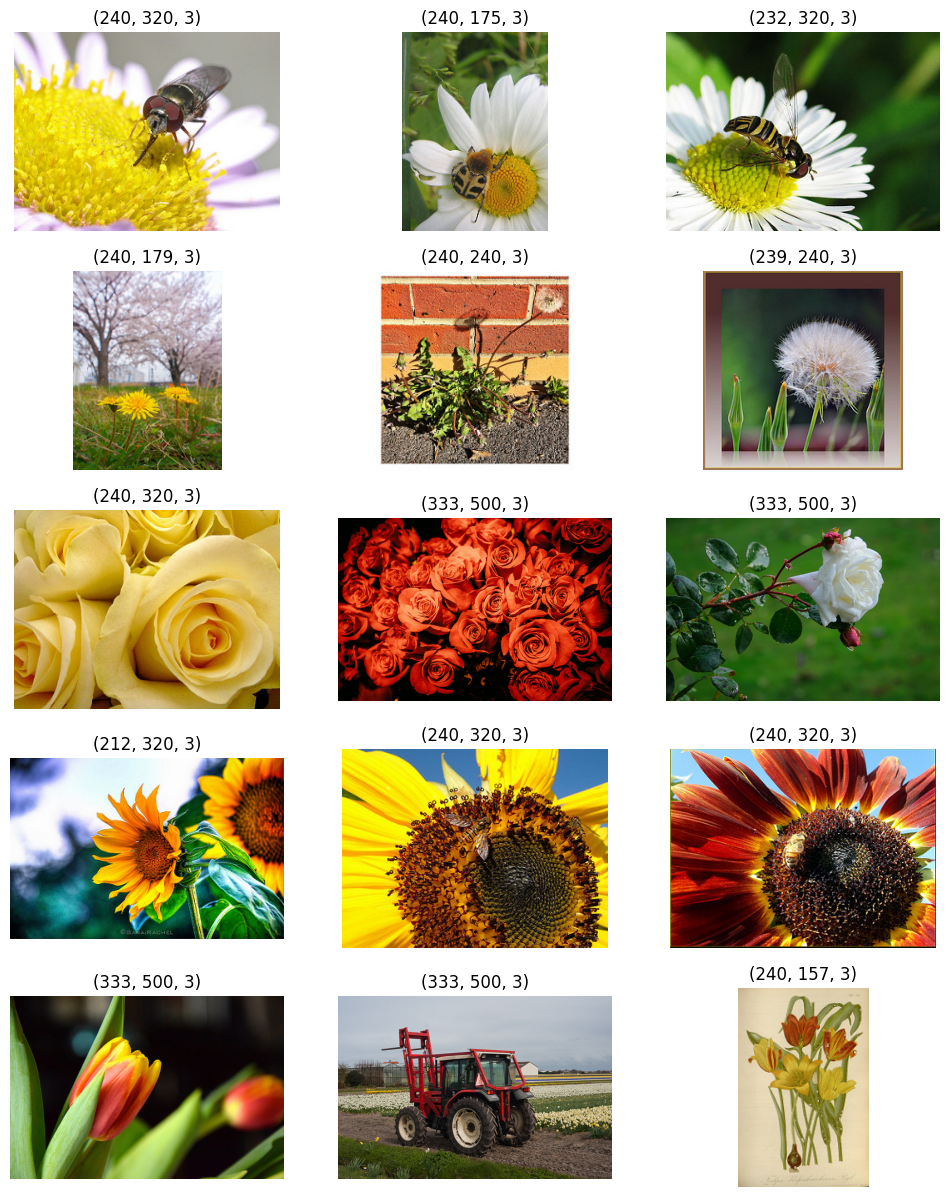

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg # Función para cargar imágenes

# Representamos esas tres imágenes de cada clase.
plt.figure(figsize=(12,15)) # ancho=12, alto=15

# Iteramos sobre cada clase y sus 3 imágenes
for i, img_path in enumerate(daisy_pix + dandelion_pix + roses_pix + sunflowers_pix + tulips_pix):
  sp = plt.subplot(5,3,i+1)     # Va a ver en cada fila 3 imagenes, y en total 5 filas
  sp.axis('Off')                # Ocultamos los ejes
  img = mpimg.imread(img_path)  # Cargamos la imagen desde su ruta
  plt.title(img.shape)          # El titulo de cada imagen es el shape
  plt.imshow(img)               # Mostramos la imagen

# c) Modelo 1: CNN básica (objetivo: accuracy_valid > 60%)


Implemente una red convolucional para resolver el problema de clasificación. Para ello se sugiere una CNN con 3 capas convolucionales + pooling con la siguiente estructura:

Bloque de procesamiento de imagen:
1.   32 kernels -> 64 kernels -> 96 kernels
2.   kernels de 3x3.
3.   Stride = 1 y padding = SI.
4.   Función de activación ReLU.
5.   Maxpooling de 2x2 con stride clásico de 2 pixeles.
6.   Igualamos el tamaño de todas las imágenes a 150 x 150.

Bloque de decisión:
7.   Capa densa de 512 neuronas.
8.   Capa densa de salida.

**Tarea 4: Define un modelo con la estructura anterior**



Para definir el modelo lo podemos hacer de dos maneras:

* **Forma sequencial**: Su estructura es lineal, debemos poner capa tras capa, una después de otra. Y, no puede tener capas con múltiples entradas o salidas.
* **Mediante la API funcional**: Puede tener múltiples entradas y salidas, y permite conexiones no lineales. Suele aplicarse en situaciones donde la forma sequential no puede ser utilizada. Se le suele denominar _grafo de capas_.

Para este primer modelo lo vamos a realizar de forma sequencial.

In [ ]:
model = keras.Sequential()

#Entrada: (150,150,3)
model.add(keras.layers.Conv2D(
                filters=32,                # Número de filtros
                kernel_size = (3,3),       # Tamaño del filtro, puede ser un número o tupla (Podriamos poner 3)
                strides = (1,1),           # Longitud del paso de la convolución. Este es el valor por defecto
                padding='same',            # Utiliza padding, el valor por defecto es 'valid'
                activation='relu',         # Función de activación
                name = 'conv1',            # Especificamos el nombre de la capa
                input_shape=(150,150,3)))  # Especificamos que entrada queremos

#Entrada: (150,150,32)
model.add(keras.layers.MaxPooling2D(
                pool_size=(2,2),  # máximo de cada bloque 2x2, puede ser un entero o tupla.
                strides = (2,2))) # Cuando pasos se mueve la ventana
                                  # Si no lo especificamos (None), se usa el valor de pool_size

#Entrada: (75, 75, 32)
                            # No especificamos los demás parámetros, ya que usamos el por defecto
model.add(keras.layers.Conv2D(64, 3, padding= 'same',activation='relu', name='conv2'))
                              # Número de filtros: 64
                              # Tamaño del filtro: (3,3)
                              # Si hay padding
                              # Función de activación= Relu

#Entrada: (75, 75, 64)
model.add(keras.layers.MaxPooling2D(2)) # pool_size y strides = (2,2)

#Entrada: (37, 37, 64)
model.add(keras.layers.Conv2D(96, 3, padding='same', activation='relu', name='conv3'))
                              # Número de filtros: 96
                              # Tamaño del filtro: (3,3)
                              # Si hay padding
                              # Función de activación= Relu

#Entrada: (37,37,96)
model.add(keras.layers.MaxPooling2D(2)) # pool_size y strides = (2,2)

#Entrada: (18, 18, 96)
model.add(tf.keras.layers.Flatten())

# Entrada: 18*18*96 = 31104
model.add(keras.layers.Dense(units= 512,  # Número de neuronas en esta capa
                             activation='relu')) # Función de activación: Relu
model.add(keras.layers.Dense(units=5, activation = 'softmax'))
        # Para la última capa, tendrá 5 neuronas, una por cada clase y, la función de activación será softmax porque hay más de una clase

**Tarea 5: Indica el shape de la imagen antes y después de cada capa de la red. Explica cómo has obtenido dichos valores**

|Capa| Shape a la salida| #parámetros |
|:-|:-:|:-:|
|Conv_1|(None, 150,150,32)|896
|Pool_1|(None, 75,75,32)|0
|Conv_2|(None, 75,75,64)|18496
|Pool_2|(None, 37,37,64)|0
|flatten|(None, 31104)|0
|densa_1|(None, 5)|2565






SHAPE DE LA IMAGEN

* Inicialmente la imagen tiene tamaño (150, 150, 3), es decir es de tamaño 150x150 con 3 canales.
* Salida conv_1: Al aplicarse padding, se mantiene el tamaño 150x150, ya que añade píxeles alrededor del borde de la entrada antes de aplicar el filtro convolucional. Varia el número de canales, que en este caso es 32, ya que se aplica 32 filtros.
* Entrada Pool_1: (150,150,32)
* Salida Pool_1: Utilizamos un bloque de 2x2 con stride 2, por lo tanto, cada 4 píxeles se reduce a 1. Es decir, El tamaño de reduce a la mitad. El número de canal no varia ya que el objetivo del pooling es reducir el tamaño, pero no los mezcla ni crea nuevos.
* Entrada conv_2: (75, 75, 32)
* Salida conv_2: Parecido al anterior, al aplicar padding no varia el tamaño. Y el número de canales es 64.
* Entrada Pool_2: (75, 75, 64)
* Salida Pool_2: Se reduce a la mitad el tamaño, igual que la capa de pooling anterior. En este caso, al reducirlo a la mitad, el resultado es decimal (75/2 = 37.5). Debido a que no se aplica padding en esta capa, truncamos.
* Entrada conv_3: (37, 37, 64)
* Salida conv_3: El tamaño sigue siendo el mismo, al aplicarse padding. Y el numero de canales es 96.
* Entrada Pool_3: (37, 37, 96)
* Salida Pool_3: Igual que las capas de pooling anterior. El tamaño se reduce a la mitad y el número de canales es igual.
* Entrada Flatten: (18, 18, 96)
* Salida Flatten: Esta capa permite conectar el bloque de preprocesamiento con el bloque de clasificación. Convierte la salida multidimensional en un vector unidimensional, para que pueda ser procesado por capas densas.
El calculo que se haría: 18x18x96 = 31104.
* Entrada dense: (31104, )
* Salida dense: Se especifica que esta capa tiene 512 neuronas.
* Entrada dense_1: (512, )
* Salida dense_1: Tenemos 5 clases, por lo tanto, hay 5 neuronas.



PARAMETROS DEL MODELO
* conv_1: (3 x 3) x 3 x 32 + 32 = 896 (kernel_size_v x kernel_size_h x #channels x #kernels) + kernels
* conv_2: (3 x 3) x 32 x 64 + 64 = 18496
* conv_3: (3 x 3) x 64 x 96 + 96 = 55392
* max_pooling: No tiene parametros
* flatten: No tiene parametros
* dense: 31104 x 512 + 512 = 15925760
* output_layer = 512 x 5 + 5= 2565


**Tarea 6: Compara el resultado con un summary() del modelo**


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 37, 37, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 31104)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    15,925,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,003,109 (61.05 MB)

 Trainable params: 16,003,109 (61.05 MB)

 Non-trainable params: 0 (0.00 B)

**Tarea 7: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 60%.**

* Utilice el optimizador que considere más adecuado.
*   Recuerda que si no se realiza conversión a One-Hot de la etiqueta a predecir, debes utilizar como función de error `SparseCategoricalCrossentropy` (este es el procedimiento que hemos usado en clase).
*   Considera un learning rate en el entorno de 0.001.
*   En el caso de los generators utiliza `class_mode='sparse'`.
*   Puedes utilizar p.e. un `batch_size = 100`.

En primer lugar, vamos a asignar la función de error y el optimizador.

La función de error para este problema, ya que no se ha usado conversión a One-Hot, sería: `SparseCategoricalCrossentropy`. Esta funcion de error es utilizada para clasificación multiclase. Calcula la distancia entre las salidas del modelo y las etiquetas verdaderas, que están representadas como enteros. Mediante `class_mode=sparse`, especificado en los generators, permite que las etiquetas sean enteros.

Por otro lado, existe algunos optimizadores que se podrian usar:

* **SGD**: No tiene "memoria" de gradientes anteriores.
* **momentum**: Utiliza un histórico de gradientes, en lugar del gradiente local.
* **Adam**: Gradiente adaptativo.

Para saber que optimizador utilizar, vamos a representar el comportamiento durante el entrenamineto en función del optimizador. Con esto, veremos cual se comporta mejor.

Sin embargo, antes debemos especificar varias cosas, para poder entrenar el modelo.

Como best-practice, creamos un callback con paciencia 4. Sirve para evitar que el overfitting aparezca. El entrenamiento se para cuando ese número que hemos puesto, que sería el número de épocas, no mejora el error de validación. Una vez detenido, los pesos del modelo van a ser los correspodientes a la época en la que alcanzó el mínimo de la función de error.

In [ ]:
es_callback = keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)
                      # patience: La paciencia que le asignamos
                      # restore_best_weights=True: Restaura los pesos del modelo en el punto en que obtuvo mejor rendimiento de validación

A continuación, vamos a utilizar `ImageDataGenerators`. Esto permite:

* Generar tensores de imágenes.
* Acceder a la estructura de carpetas y asociar a cada imagen la clase a partir del nombre de la carpeta.
* Preprocesar las imagenes.

Primero, inicializamos un generador para train y para validación, normalizando las imágenes.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
                          # rescale: Los píxeles de imágenes son escalados, dividiendose por 255.
                          # Es entre 255, ya que los píxeles van de 0 a 255, y queremos normalizarlo al rango [0,1]
val_datagen = ImageDataGenerator(rescale=1./255)

Después, indicamos a los generadores:

* La ruta de las imágenes.
* El tamaño del batch que queremos que traiga las imágenes de los directorios.
* Un tamaño fijo para todas las imágenes.

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,                    # Directorio de las imágenes
    target_size = (150,150),      # Tamaño fijo de las imágenes
    batch_size = 100,             # Tamaño del batch
    class_mode = 'sparse')        # Las clases se codifican como enteros

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = (150,150),
    batch_size = 100,
    class_mode = 'sparse')

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


Definido esto, entrenamos el modelo para cada optimizador. Para no ir copiando el modelo entero en cada entrenamiento, se va a utilizar `clone_model`. Esto permite copiar el modelo para probar los distintos optimizadores sin que un entrenamiento afecte al siguiente.

In [ ]:
# Lo importamos
from tensorflow.keras.models import clone_model

In [ ]:
# SGD
modelo_sgd = clone_model(model) # Realizamos una copia del modelo

modelo_sgd.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # Error entropía cruzada
              optimizer = keras.optimizers.SGD(learning_rate=0.001), # Optimizador SGD
              metrics=['accuracy'])

history_sgd = modelo_sgd.fit(
    train_generator, # Generador de imágenes
    steps_per_epoch = 30,  # Numero de pasos. -> 2935 images = batch_size * steps, steps = 30
    epochs = 20, # Número total de pasadas completas en el dataset de entrenamiento
    validation_data = validation_generator, # Generador de datos, para evaluar el modelo después de cada época
    validation_steps = 8, # 735 images = batch_size * steps, steps = 8
    callbacks = [es_callback], # EarlyStopping
    verbose = 0) # No muestra los resultados de cada época


In [ ]:
# MOMENTUM
modelo_mom = clone_model(model) # Realizamos una copia del modelo


modelo_mom.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # Error entropía cruzada
              optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9), # Optimizador momentum
                                # Asignamos β=0.9
              metrics=['accuracy'])

history_mom = modelo_mom.fit(
    train_generator, # Generador de imágenes
    steps_per_epoch = 30,  # Numero de pasos. -> 2935 images = batch_size * steps, steps = 30
    epochs = 20, # Número total de pasadas completas en el dataset de entrenamiento
    validation_data = validation_generator, # Generador de datos, para evaluar el modelo después de cada época
    validation_steps = 8, # 735 images = batch_size * steps, steps = 8
    callbacks = [es_callback], # EarlyStopping
    verbose = 0) # No muestra los resultados de cada época

In [ ]:
# ADAM
modelo_adam = clone_model(model) # Realizamos una copia del modelo

modelo_adam.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # Error entropía cruzada
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001), # Optimizador Adam
              metrics=['accuracy'])

history_adam = modelo_adam.fit(
    train_generator, # Generador de imágenes
    steps_per_epoch = 30,  # Numero de pasos. -> 2935 images = batch_size * steps, steps = 30
    epochs = 20, # Número total de pasadas completas en el dataset de entrenamiento
    validation_data = validation_generator, # Generador de datos, para evaluar el modelo después de cada época
    validation_steps = 8, # 735 images = batch_size * steps, steps = 8
    callbacks = [es_callback], # EarlyStopping
    verbose = 0) # No muestra los resultados de cada época

Text(0, 0.5, 'error')

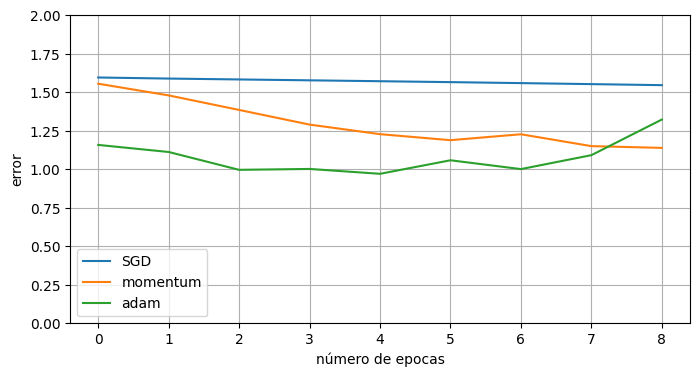

In [ ]:
# En cada entrenamiento se obtiene diferentes número de épocas y para poder representar la gráfica tenemos que tener lo mismo.
# Nos quedamos con el número de épocas más pequeño
min_epoch = min(len(history_sgd.history['val_loss']),
                len(history_mom.history['val_loss']),
                len(history_adam.history['val_loss']))

# Creamos un DataFrame con los errores de validación
df_opt = pd.DataFrame({'SGD': history_sgd.history['val_loss'][:min_epoch],
                       'momentum': history_mom.history['val_loss'][:min_epoch],
                       'adam': history_adam.history['val_loss'][:min_epoch]})

df_opt.plot(figsize=(8,4))
plt.grid(True)
plt.ylim(0, 2)
plt.xlabel('número de epocas')
plt.ylabel('error')


Observando la gráfica, SGB está entrenando muy lento, apenas se aprecia la mejora con respecto a los otros dos optimizadores. Por lo tanto, lo mejor seria utilizar momemtum o adam.

Por otro lado, comparando estos dos últimos optimizadores, adam es el que menos error tiene, aunque a parir de ciertas epoch, empieza ha subir (esto lo explicaremos porque ocurre más adelante), mientras que momentum mejora la función de error poco a poco.

Finalmente, para este modelo vamos a utilizar el optimizador adam, ya que converge rápido, con el learning rate ajusta automáticamente cada parámetro y se adapta bien a la mayoria de datasets.

Una vez elegido el optimizador, vamos a volver a asignar la función de error y el optimizador, para entrenar el modelo sin realizar ninguna copia. Además, veremos los resultados de cada época mientras que el modelo entrena.

In [ ]:
#Asignamos la función error y el optimizador
model.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # Error entropía cruzada
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001), # Optimizador Adam, el que hemos elegido
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_generator, # Generador de imágenes
    steps_per_epoch = 30,  # Numero de pasos. -> 2935 images = batch_size * steps, steps = 30
    epochs = 20, # Número total de pasadas completas en el dataset de entrenamiento
    validation_data = validation_generator, # Generador de datos, para evaluar el modelo después de cada época
    validation_steps = 8, # 735 images = batch_size * steps, steps = 8
    callbacks = [es_callback], # EarlyStopping
    verbose = 2) # Muestra los resultados de cada época

Epoch 1/20
30/30 - 12s - 407ms/step - accuracy: 0.3029 - loss: 1.9957 - val_accuracy: 0.3333 - val_loss: 1.4615
Epoch 2/20
30/30 - 8s - 265ms/step - accuracy: 0.4729 - loss: 1.2225 - val_accuracy: 0.4884 - val_loss: 1.1956
Epoch 3/20
30/30 - 10s - 335ms/step - accuracy: 0.5721 - loss: 1.0522 - val_accuracy: 0.5810 - val_loss: 1.0650
Epoch 4/20
30/30 - 7s - 243ms/step - accuracy: 0.6273 - loss: 0.9377 - val_accuracy: 0.6163 - val_loss: 1.0166
Epoch 5/20
30/30 - 10s - 345ms/step - accuracy: 0.6923 - loss: 0.8078 - val_accuracy: 0.6299 - val_loss: 0.9786
Epoch 6/20
30/30 - 10s - 338ms/step - accuracy: 0.7308 - loss: 0.7123 - val_accuracy: 0.5619 - val_loss: 1.1304
Epoch 7/20
30/30 - 11s - 358ms/step - accuracy: 0.7775 - loss: 0.5897 - val_accuracy: 0.5986 - val_loss: 1.0573
Epoch 8/20
30/30 - 8s - 256ms/step - accuracy: 0.8467 - loss: 0.4421 - val_accuracy: 0.6000 - val_loss: 1.1563
Epoch 9/20
30/30 - 11s - 366ms/step - accuracy: 0.8865 - loss: 0.3405 - val_accuracy: 0.6068 - val_loss: 1.

El mejor rendimiento del modelo sobre el conjunto de validación es 0.6299. Esto ocurre en la época 5.

**Tarea 8: Muestra la evolución de la función de error (train y valid) durante el entrenamiento.Explica que problema presenta el modelo que hemos entrenado.**

Por último, vamos a representar la evolución de la función de error durante el entrenamiento.

Text(0.5, 1.0, 'Training and validation loss')

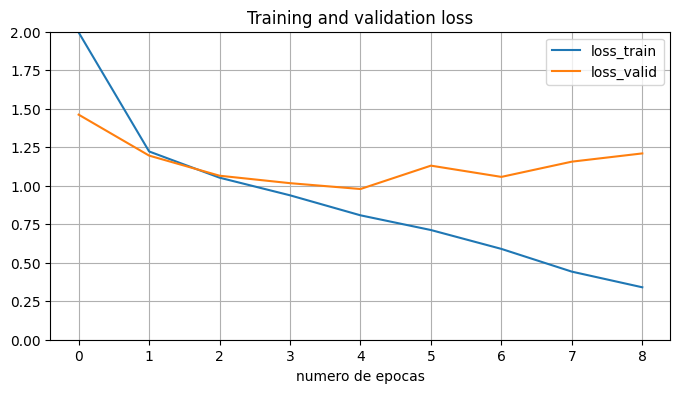

In [ ]:
pd.DataFrame({'loss_train': history.history['loss'], # Error de entrenamiento
              'loss_valid': history.history['val_loss']}).plot(figsize=(8,4)) # Error de validación

plt.grid(True)  # Muestra lineas horizontales y verticales
plt.ylim(0,2)   # Rango de valores del eje y
                # Es [0,2], ya que los errores según la evolución del entrenamiento se mueven en ese rango
plt.xlabel('numero de epocas')
plt.title('Training and validation loss')

Viendo la gráfica, podemos observar que el error de entrenamiento va disminuyendo, por lo tanto, el modelo está aprendiendo bien los datos de entrenamiento. Sin embargo, el error de validación comienza a aumentar después de varias épocas. Esto indica que existe un problema de overfitting. El modelo "memoriza" los datos de entrenamineto y en los datos de validación no clasifica bien.

# d) Modelo 2: reducción del overfitting (objetivo: accuracy_valid > 70%)

Para mejorar el accuracy del modelo, vamos a incorporar las dos técnicas más habituales de reducción del overfitting:

    * drop-out
    * data augmentation
    

**Tarea 9: Explica en que consisten y qué utilidad tienen para nuestro problema**





Las dos técnicas más habituales son:

* Drop-out: Consiste en "apagar" aleatoriamente algunas neuronas en la capa que le apliquemos el dropout. En cada paso no se apagan las mismas neuronas, si no que va variando. Permite no depender demasiado de ciertas neuronas y reduce que el modelo memorice los datos.

* Data Augmentation: Consiste en generar nuevas imágenes a partir del conjunto de datos de entrenamiento. Esto es, a partir de modificaciones sobre los datos originales, obtenemos nuevas imágenes con lo que expandir el conjunto de train. Además, ayuda al modelo a generalizar mejor y que no memorice el conjunto de entrenamiento.

En nuestro problemas estas técnicas nos pueden ayudar a evitar el sobreajuste, ya que, con DataAugmentation el modelo va a permitir reconocer las imágenes independientemente de como esté posicionada, ya que vamos a añadir nuevos datos con diferentes tipos de transformaciones. Y, con dropout, va a permitir que el modelo sea más robusto, puesto que, al "apagar" algunas neuronas no va a llegar a memorizar las caracteristicas de las imágenes.  

**Tarea 10: Construye un nuevo modelo 2 incorporando (en el modelo 1 anterior) el dropout adecuado**

Para construir este modelo, vamos a realizarlo mediante la API funcional. Tendrá la misma estructura que el modelo 1, añadiendo el dropout.

In [ ]:
img_input = keras.layers.Input(shape=(150,150,3)) # Nodo Input con las dimensiones del tensor de entrada

x = keras.layers.Conv2D(32, 3, padding='same', activation='relu')(img_input)
              # Número de filtro: 32
              # Tamaño del filtro: 3 (corresponde a (3,3))
              # padding = 'same': Si hay padding
              # Función de activación: relu
x = keras.layers.MaxPool2D(2)(x) # pool_size y strides = 2 -> (2,2)


x = keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
              # Número de filtro: 64
              # Tamaño del filtro: 3 (corresponde a (3,3))
              # padding = 'same': Si hay padding
              # Función de activación: relu
x = keras.layers.MaxPool2D(2)(x) # pool_size y strides = 2 -> (2,2)


x = keras.layers.Conv2D(96, 3, padding='same', activation='relu')(x)
              # Número de filtro: 96
              # Tamaño del filtro: 3 (corresponde a (3,3))
              # padding = 'same': Si hay padding
              # Función de activación: relu
x = keras.layers.MaxPool2D(2)(x) # pool_size y strides = 2 -> (2,2)


x = keras.layers.Flatten()(x) # Capa flatten


# Capas densas
x = keras.layers.Dense(512, activation='relu')(x) # Hay 512 neuronas y la función de activación es Relu
x = keras.layers.Dropout(0.5)(x) # Aleatoriamente apagamos el 50% de las neuronas

output = keras.layers.Dense(5, activation='softmax')(x) # La capa de salida, tiene 5 neuronas, uno por cada capa,
                                                        # y funcion de activacion softmax

model2 = keras.Model(img_input, output) # Creamos el modelo

**Tarea 11: Explica que tipos de augmentation vas a considerar y que utilidad tienen en nuestro problema de clasificacion**

Existe muchos tipos de augmentation, sin embargo, en nuestro problema vamos a utilizar:

* **Rotación**: Permite que las flores aparezcan con diferentes orientaciones. Se le dará una orientacion de rango 30º para no alterar demasiado las imágenes.
* **Desplazamiento**: Las imagenes se puede desplazar tanto a la izquierda como a la derecha, ya que las posiciones de las flores no siempre van a estar en el centro.
* **Corte**: Simula cambios en la perspectiva.
* **Zoom**: Permite acercar o alejar las imágenes, y ver las flores más de cerca o lejos.
* **Flip horizontal**: Podemos voltear horizontalmente las imágenes, ya que muchas flores son simétricas.
* **Iluminación**: Al variar el brillo de las fotos, permitimos que el modelo aprenda frente a cambios de iluminación, ya que en las imágenes puede haber cambios de luz. Sin embargo, variaremos muy poco para que no afecte al color de las fotos.


**Tarea 12: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 70%.**

Debido a que vamos a aplicar DataAugmentation, debemos definir nuevos DataGenerators.

In [ ]:
# Inicializamos los generadores, generando nuevas imágenes
train_datagen2 = ImageDataGenerator(
    rescale = 1./255,                 # Normalizamos los píxeles
    rotation_range=30,                # Rotacion, rango de 30º
    width_shift_range=0.2,            # Desplazamiento horizontal, hasta 20% del ancho
    height_shift_range=0.2,           # Desplazamiento vertical, hasta 20% del alto
    shear_range=0.2,                  # Aplica corte a las imágenes, hasta 20º
    zoom_range=0.2,                   # Zoom, aleatoriamente entre 80% y 120%
    horizontal_flip = True,           # Voltea horizontalmente
    brightness_range = [0.9, 1.1]     # Variar el brillo, puede oscurecer o aclarar

)

val_datagen2 = ImageDataGenerator(rescale=1./255)
# En los datos de validación no aplicamos las transformaciones ya que este conjunto de datos permite evaluar el rendimiento del modelo, con imágenes sin alterar.

In [ ]:
# Definimos los generadores con los tipos de Augmentation anteriores.
train_generator2 = train_datagen2.flow_from_directory(
    train_dir,                  # Directorio de las imágenes
    target_size = (150,150),    # Tamaño fijo de las imágenes
    batch_size = 100,           # Tamaño del batch
    class_mode = 'sparse')      # Codificamos las clases como enteros

validation_generator2 = val_datagen2.flow_from_directory(
    val_dir,
    target_size = (150,150),
    batch_size = 100,
    class_mode = 'sparse')

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


Asignamos la función de error y el optimizador. Esto estará definido igual que el modelo anterior.

In [ ]:
model2.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # Error entropía cruzada
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001), # Optimizador Adam
              metrics=['accuracy'])

Entrenamos el nuevo modelo creado.

In [ ]:
history2 = model2.fit(
    train_generator2, # Generador de las imágenes
    steps_per_epoch = 30, # Numero de pasos -> 2935 images = batch_size * steps, steps = 30
    epochs = 40, # Número total de pasadas completas en el dataset de entrenamiento
    validation_data = validation_generator2, # Generador de datos, para evaluar el modelo después de cada época
    validation_steps = 8, # Número de pasos -> 735 images = batch_size * steps, steps = 8
    callbacks = [es_callback], # EarlyStopping
    verbose = 2) # Muestra los resultados de cada época

Epoch 1/40
30/30 - 29s - 973ms/step - accuracy: 0.3404 - loss: 1.5975 - val_accuracy: 0.5007 - val_loss: 1.2236
Epoch 2/40
30/30 - 24s - 807ms/step - accuracy: 0.4627 - loss: 1.2210 - val_accuracy: 0.5497 - val_loss: 1.1537
Epoch 3/40
30/30 - 24s - 808ms/step - accuracy: 0.5145 - loss: 1.1576 - val_accuracy: 0.5891 - val_loss: 1.0749
Epoch 4/40
30/30 - 24s - 810ms/step - accuracy: 0.5540 - loss: 1.0784 - val_accuracy: 0.6014 - val_loss: 1.0495
Epoch 5/40
30/30 - 24s - 805ms/step - accuracy: 0.5952 - loss: 1.0409 - val_accuracy: 0.5973 - val_loss: 1.0390
Epoch 6/40
30/30 - 41s - 1s/step - accuracy: 0.6170 - loss: 0.9956 - val_accuracy: 0.6177 - val_loss: 0.9820
Epoch 7/40
30/30 - 24s - 812ms/step - accuracy: 0.6198 - loss: 0.9699 - val_accuracy: 0.5878 - val_loss: 1.0799
Epoch 8/40
30/30 - 24s - 809ms/step - accuracy: 0.6402 - loss: 0.9232 - val_accuracy: 0.6463 - val_loss: 0.9157
Epoch 9/40
30/30 - 24s - 808ms/step - accuracy: 0.6586 - loss: 0.8927 - val_accuracy: 0.6735 - val_loss: 0.

El mejor rendimiento del modelo sobre el conjunto de validación es 0.7401, esto ocurre en la época 22. Sin embargo, al aplicar EarlyStoping sobre val_loss, guardaría los datos de la época 19.

**Tarea 13: Muestra la evolucion de la funcion de error durante el entrenamiento. Explica qué diferencias de comportamiento hay entre las gráficas del modelo 1 y el modelo 2**

Text(0.5, 1.0, 'Trainiing and validation loss')

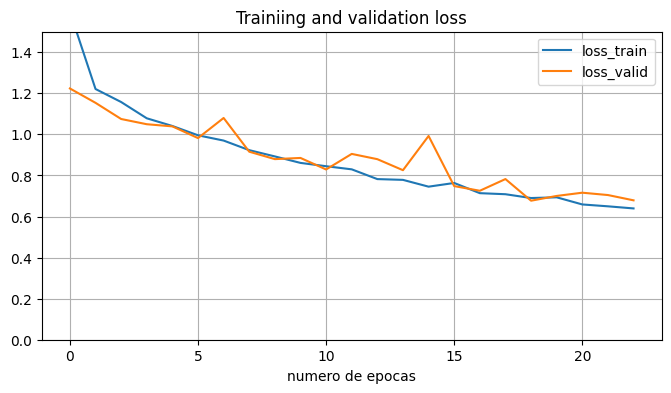

In [ ]:
pd.DataFrame({'loss_train': history2.history['loss'], # Error de entrenamiento
              'loss_valid': history2.history['val_loss']}).plot(figsize=(8,4)) # Error de validación

plt.grid(True)
plt.ylim(0,1.5) # Le damos este rango, ya que hay veces que los errores alcanza estos valores
plt.xlabel('numero de epocas')
plt.title('Trainiing and validation loss')

Comparando ambas gráficas, al haber aplicado a este último modelo drop-out y data Augmentation, el error de validación va disminuyendo, y se mantiene cerca del error de entrenamiento. Esto significa que generaliza mejor y no llega a memorizar los datos. Además, realiza más número de épocas, en compración con el modelo anterior.

Sin embargo, comparando ambos errores de entrenamiento, al haber añadido en este último estas técnicas,  dicho error no disminuye tan rápido como en el primer modelo. Esto es, porque al "apagar" neuronas no memoriza las caracteristicas y recibe imágenes distintas por Augmentation.

# c) Modelo 3: Transfer Learning (objetivo: accuracy_valid > 88%)

En nuestro problema de clasificación de flores, el utilizar CNNs diseñadas y entrenadas por nosotros mismos, aparece una barrera en las proximidades del 75-77% de precisión del modelo (siempre sobre validación).

Para superar este escollo, el siguiente paso natural es la utilización de modelos preentrenados. Existe una gran variedad de ellos basados en redes CNNs clásicas, donde la principal diferencia es que acumulan más capas que nuestros modelos 1 y 2. Adicionalmente, en estos modelos se han ido incorporando diferentes propuestas para mejorar la arquitectura de la CNN.

En general, utilizando estos modelos convolucionales preentrenados podemos alcanzar accuracies próximos al 90%. Normalmente, estos modelos han sido previamente entrenados sobre datasets de gran tamaño y con gran número de categorías. P.e. en subconjuntos de Imagenet (14 millones de imagenes de 22K categorías).

Dado que estos modelos se entrenaron para resolver un problema "relativamente" parecido a nuestro problema de clasificación, parece razonable pensar que podemos aprovechar ese conocimiento capturado en la red para resolver nuestro problema de clasificación de flores.



Para elegir el modelo preentrenado que debe utilizar cada grupo, proceda del siguiente modo:
* Paso 1: sume los DNIs de los componentes del grupo (si el grupo tiene un sólo miembro, vaya directamente al paso 2). res = dni_1 + dn_2
* Paso 2: Aplique la siguiente operación al resultado anterior: res mod 6.
* Paso 3: Tome el modelo cuyo número asociado coincide con el resultado de la operación anterior.
* Paso 4: El porcentaje que aparece entre paréntesis junto al nombre del modelo es el accuracy (en validación) que deberías poder alcanzar sin dificultad utilizando el modelo. En todos los casos considera un input_shape = (224, 224, 3).

  0. Resnet50 (>90%)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/ResNet50

  1. Resnet101 (>90%) input_shape = (224, 224, 3)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/ResNet101

  2. VGG16 (>90%) input_shape = (224, 224, 3)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/VGG16

  3. VGG19 (>90%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg19/VGG19

  4. Xception (>88%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/xception/Xception

  5. Inceptionv3 (>88%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/InceptionV3

P.e. si los DNIs de los alumnos son: 12345678 y 23456781. La suma es 35802459. De donde 35802459 mod 6 = 3. Por tanto, tomaríamos el modelo VGG16.

Recuerda que puedes utilizar el siguiente post como referencia del uso de transfer learning: https://www.learndatasci.com/tutorials/hands-on-transfer-learning-keras/

**Tarea 14: Importa el modelo desde Tensorflow**

Dado que este modelo ha sido entrenado para clasificar entre 1.000 categorías, las capas densas finales del modelo no son útiles para nuestro problema de clasificación de 5 categorías (es lo que suele llamarse include_top = SI/NO). De manera que eliminamos lo que a veces se suele llamar el "top model". De este modo sólo nos quedamos con la parte que hace la funcionalidad de "procesamiento" de la imagen.

En primer lugar importamos el modelo.

In [ ]:
from keras.applications import ResNet50
from keras.applications.resnet import preprocess_input
# preprocess_input será necesario a continuación para el generador de imágenes

In [ ]:
conv_base = ResNet50(include_top=False, #indicamos este parametro como False para indicar que no queremos la parte superior del modelo
                     input_shape=(224,224,3), # el tamaño de entrada del modelo
                     weights='imagenet' # Cargamos los pesos ya preentrenados
                     )

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


**Tarea 15: Personalizar el bloque de decisión**  
Añadimos una capa de flatten y tres nuevas capas densas especificas para nuestro problema con dimensiones 4096, 1072 y la que necesite la capa de salida (con sus correspondientes drop-outs).

Representamos el modelo mediante la API funcional.

In [ ]:
x = keras.layers.Flatten()(conv_base.output) # Capa flatten que se le pasa el output del modelo anterior
# Capas densas
x = keras.layers.Dense(4096, activation='relu')(x) # Primera capa densa hay 4096 neuronas y la función de activación es Relu
x = keras.layers.Dropout(0.5)(x) # Aleatoriamente apagamos el 50% de las neuronas
x = keras.layers.Dense(1072, activation='relu')(x) # Segunda capa densa hay 1072 neuronas y la función de activación es Relu
x = keras.layers.Dropout(0.5)(x) # Aleatoriamente apagamos el 50% de las neuronas
output = keras.layers.Dense(5, activation='softmax')(x) # La capa de salida, tiene 5 neuronas, uno por cada clase,
                                                        # y funcion de activacion softmax
modelC = keras.Model(conv_base.input, output) # Creamos el modelo


**Tarea 16: Congelar los pesos que no se vayan a entrenar**

Previo a hacer el denominado `Fine-Tuning` del modelo, indicaremos a Tensorflow que únicamente debe entrenar:

   * Las dos últimas capas convolucionales de la red preentrenada, de las que realizaremos un ajuste fino de los pesos.
   * Las tres capas densas que hemos incluido nuevas.

In [ ]:
modelC.trainable = True
# En principio las capas son entrenables, es decir estan descongeladas
for layer in modelC.layers:
  # por cada capa del modelo
    # si es una capa convolucional
    if layer in conv_base.layers[:-2]:
        layer.trainable = False # congelamos las capas convolucionales menos las 2 ultimas
# descomentar esta linea para ver como resultav el modelo:   modelC.summary(show_trainable=True)

**Tarea 17: Crear los datagenerators oportunos**

Para ello:
> * Utiliza Data augmentation.  
> * Las imágenes tienen que ser preprocesadas igual que cuando se entrenó el modelo pre.entrenado original. Para ello se utiliza el parámetro `preprocessing_function=preprocess_input` (preprocess_input importado desde `keras.applications.xxxxxx` en ambos generators (train y valid). Por tanto, no hay que indicarle `rescale`. En caso de ser necesario, se encargará `preprocess_input`.  
> * Dado que estamos reutilizando un modelo que no "es nuestro", deberemos ceñirnos al tamaño de imagen que permite la red a la entrada. Recuerda que debe ser: 224x224.

In [ ]:
## Aplicamos el mismo Data augmentation que en los apartados anteriores
# Inicializamos los generadores, generando nuevas imágenes
train_datagen3= ImageDataGenerator(
    preprocessing_function=preprocess_input,  # para el preprocesado ResNet50
    rotation_range=30,                        # Rotacion, rango de 30º
    width_shift_range=0.2,                    # Desplazamiento horizontal, hasta 20% del ancho
    height_shift_range=0.2,                   # Desplazamiento vertical, hasta 20% del alto
    shear_range=0.2,                          # Aplica corte a las imágenes, hasta 20º
    zoom_range=0.2,                           # Zoom, aleatoriamente entre 80% y 120%
    horizontal_flip = True,                   # Voltea horizontalmente
    brightness_range = [0.9, 1.1]             # Variar el brillo, puede oscurecer o aclarar
    )

# Aqui solo llamamos al ImageDataGenerator ya que estos datos son para evaluar el modelo
# si que es necesario añadir aquí también el paarametro preprocessing_function
val_datagen3 = ImageDataGenerator(preprocessing_function=preprocess_input)
# Definimos los generadores con los tipos de Augmentation anteriores.
train_generator3 = train_datagen3.flow_from_directory(
    train_dir,                  # Directorio de las imágenes
    target_size = (224,224),    # Tamaño fijo de las imágenes
    batch_size = 64,           # Tamaño del batch
    class_mode = 'sparse')      # Codificamos las clases como enteros

validation_generator3 = val_datagen3.flow_from_directory(
    val_dir,
    target_size = (224,224),
    batch_size = 64,
    class_mode = 'sparse'
    )

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


**Tarea 18: Haz el fine-tuning del modelo con el objetivo de alcanzar un accuracy (sobre el conjunto de validación > 88%).**

A la hora de entrenar un modelo pretrained es típico bajar el learning rate respecto al que utilizaríamos para un modelo nuestro desde cero.

In [ ]:
modelC.compile(loss = 'sparse_categorical_crossentropy', # Para el Error usamos la entropía cruzada
              optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3), # Usasamos el optimizador Adam como en el modelo anterior, con un learning rate muy bajo
              metrics=['accuracy'])

In [ ]:
history3 = modelC.fit(
    train_generator3, # Generador de las imágenes
    steps_per_epoch = 46 , # 2935 images = batch_size * steps, steps = 46
    epochs = 40, # Número de épocas
    validation_data = validation_generator3, # Generador de datos, para evaluar el modelo después de cada época
    validation_steps = 12, # Número de pasos -> 735 images = batch_size * steps, steps = 64
    callbacks = [es_callback], # llamamos al callback que se creo anteriormente
    verbose = 2) # Muestra los resultados de cada época

Epoch 1/40
46/46 - 95s - 2s/step - accuracy: 0.5530 - loss: 30.4013 - val_accuracy: 0.8014 - val_loss: 0.9645
Epoch 2/40
46/46 - 108s - 2s/step - accuracy: 0.7329 - loss: 1.4479 - val_accuracy: 0.8327 - val_loss: 0.5079
Epoch 3/40
46/46 - 54s - 1s/step - accuracy: 0.7608 - loss: 0.8594 - val_accuracy: 0.8422 - val_loss: 0.4745
Epoch 4/40
46/46 - 82s - 2s/step - accuracy: 0.7796 - loss: 0.7115 - val_accuracy: 0.8503 - val_loss: 0.4418
Epoch 5/40
46/46 - 54s - 1s/step - accuracy: 0.7911 - loss: 0.6693 - val_accuracy: 0.8857 - val_loss: 0.3713
Epoch 6/40
46/46 - 78s - 2s/step - accuracy: 0.8286 - loss: 0.5846 - val_accuracy: 0.8721 - val_loss: 0.3986
Epoch 7/40
46/46 - 82s - 2s/step - accuracy: 0.8276 - loss: 0.5414 - val_accuracy: 0.8517 - val_loss: 0.4095
Epoch 8/40
46/46 - 84s - 2s/step - accuracy: 0.8371 - loss: 0.5262 - val_accuracy: 0.8776 - val_loss: 0.3434
Epoch 9/40
46/46 - 82s - 2s/step - accuracy: 0.8402 - loss: 0.4878 - val_accuracy: 0.8517 - val_loss: 0.4408
Epoch 10/40
46/46

El mejor rendimiento del modelo sobre el conjunto de validación es 0.8939, esto ocurre en la época 12. Sin embargo, al aplicar EarlyStoping sobre val_loss, guardaría los datos de la época 8.

Además, podemos observar que el error sobre el conjunto de entrenamiento en la primera época es grande. Se debe a que al añadir nuevas capas (capas densas), inicialmente tienen pesos aleatorios. Por lo tanto, al principio no saben nada del problema, y cometen muchos errores. A partir de ahí, el modelo empieza a adaptarse al conjunto de datos, y el error va disminuyendo.

Representamos la evolución de la función de error durante el entrenamiento.

Text(0.5, 1.0, 'Trainiing and validation loss')

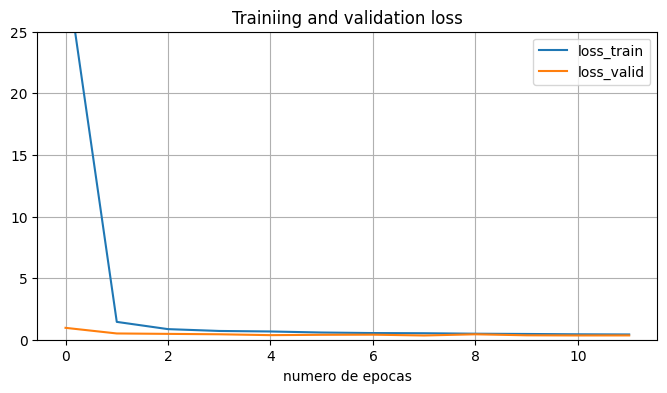

In [ ]:
pd.DataFrame({'loss_train': history3.history['loss'], # Error de entrenamiento
              'loss_valid': history3.history['val_loss']}).plot(figsize=(8,4)) # Error de validación

plt.grid(True) # Muestra lineas horizontales y verticales
plt.ylim(0,25) # Le damos este rango, ya que hay veces que los errores alcanza estos valores
plt.xlabel('numero de epocas')
plt.title('Trainiing and validation loss')